# Multitap Fractional Delay Line

A multitap delay reads independently delayed copies of a mono input from a shared buffer and places each at a stereo position using a constant-power panning law.

| Parameter | Effect |
| --- | --- |
| `taps` | List of `(delay_seconds, gain, pan)` tuples |
| `delay_seconds` | Tap position in seconds (fractional sample accuracy) |
| `gain` | Linear amplitude scaling for this tap |
| `pan` | Stereo position in [−1, 1]; −1 = full left, 0 = centre, +1 = full right |

Panning uses the constant-power law: `L = gain × cos(θ)`, `R = gain × sin(θ)` where `θ = (pan + 1) × π/4`.  
This keeps `L² + R² = gain²` at all pan positions.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.delay import multitap_delay

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Eight-Tap Stereo Echo Pattern

An impulse train (one click every 300 ms) fed through eight taps with varied delays, gains, and pan positions.  
Taps annotated T1–T8 on the channel plots.

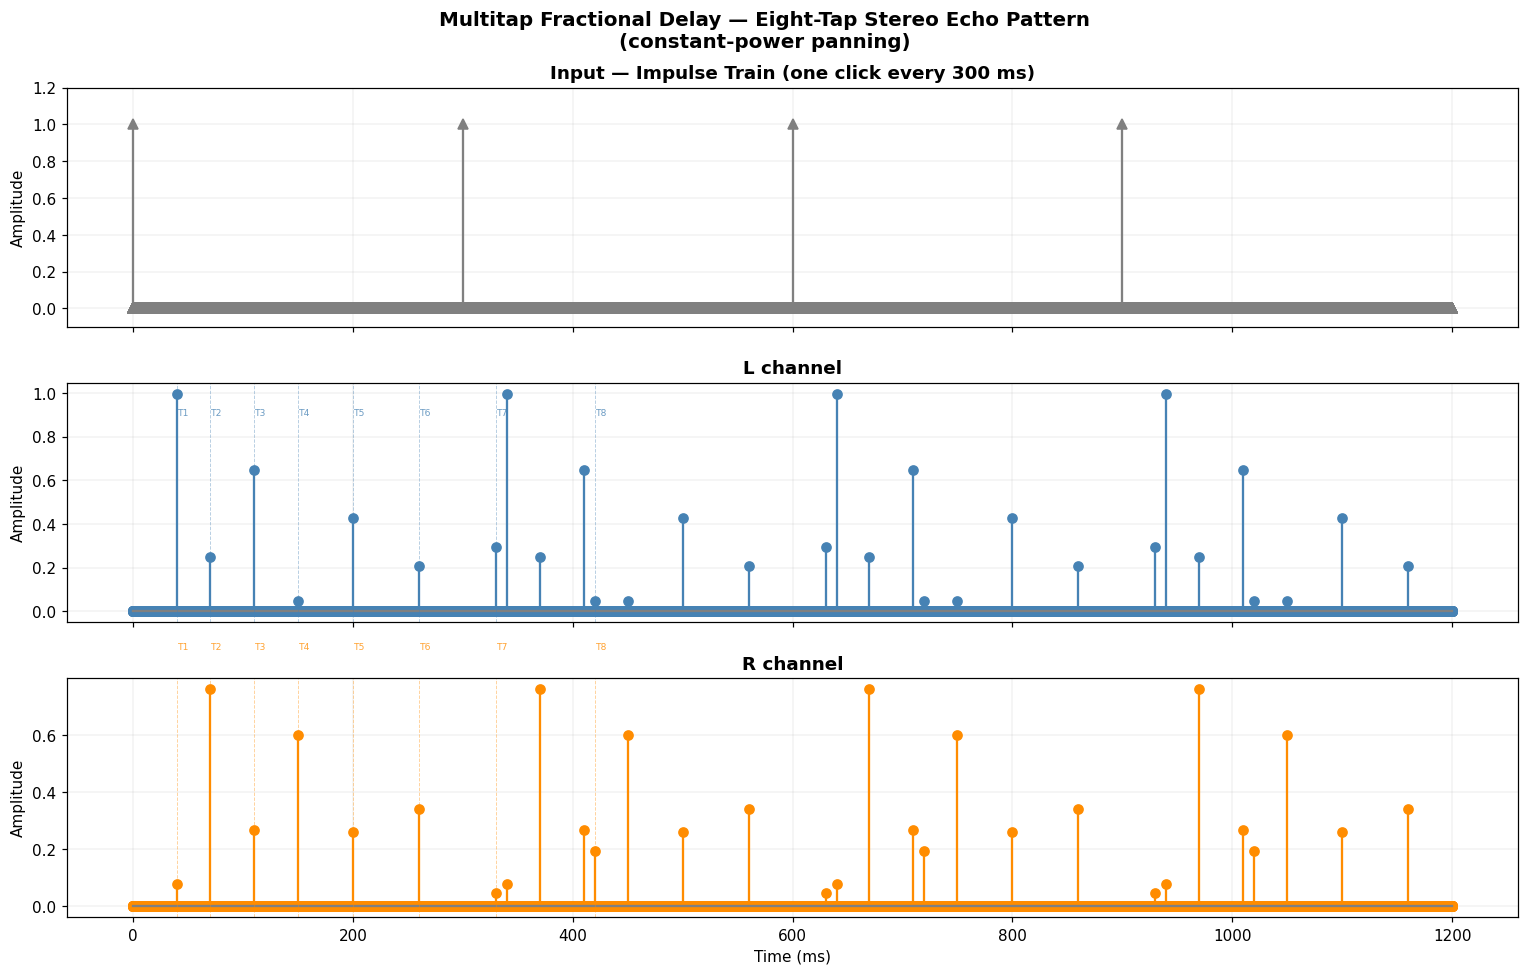

In [2]:
DURATION = 1.2
N = int(DURATION * FS)

impulse_train = np.zeros(N)
for k in range(4):
    impulse_train[round(k * 0.3 * FS)] = 1.0

t_ms = np.arange(N) / FS * 1000

TAPS = [
    (0.04,  1.00, -0.9),
    (0.07,  0.80,  0.6),
    (0.11,  0.70, -0.5),
    (0.15,  0.60,  0.9),
    (0.20,  0.50, -0.3),
    (0.26,  0.40,  0.3),
    (0.33,  0.30, -0.8),
    (0.42,  0.20,  0.7),
]

_, L, R = multitap_delay(impulse_train, FS, TAPS)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].stem(t_ms, impulse_train, linefmt='gray', markerfmt='^', basefmt='gray')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-0.1, 1.2)
axes[0].set_title('Input — Impulse Train (one click every 300 ms)', fontweight='bold')
axes[0].grid(True, linewidth=0.3, alpha=0.5)

axes[1].stem(t_ms, L, linefmt='steelblue', markerfmt='o', basefmt='gray')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('L channel', fontweight='bold')
axes[1].grid(True, linewidth=0.3, alpha=0.5)

axes[2].stem(t_ms, R, linefmt='darkorange', markerfmt='o', basefmt='gray')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (ms)')
axes[2].set_title('R channel', fontweight='bold')
axes[2].grid(True, linewidth=0.3, alpha=0.5)

for i, (dt, gain, pan) in enumerate(TAPS):
    dt_ms = dt * 1000
    for ax, col in [(axes[1], 'steelblue'), (axes[2], 'darkorange')]:
        ax.axvline(dt_ms, color=col, linewidth=0.6, linestyle='--', alpha=0.4)
        ax.text(dt_ms + 1, 0.9, f'T{i+1}', fontsize=6, color=col, alpha=0.8)

fig.suptitle(
    'Multitap Fractional Delay — Eight-Tap Stereo Echo Pattern\n'
    '(constant-power panning)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Constant-Power Panning Law

As `pan` sweeps from −1 to +1, `L = cos(θ)` decreases while `R = sin(θ)` increases,  
keeping total power `L² + R² = 1` constant across the stereo field.

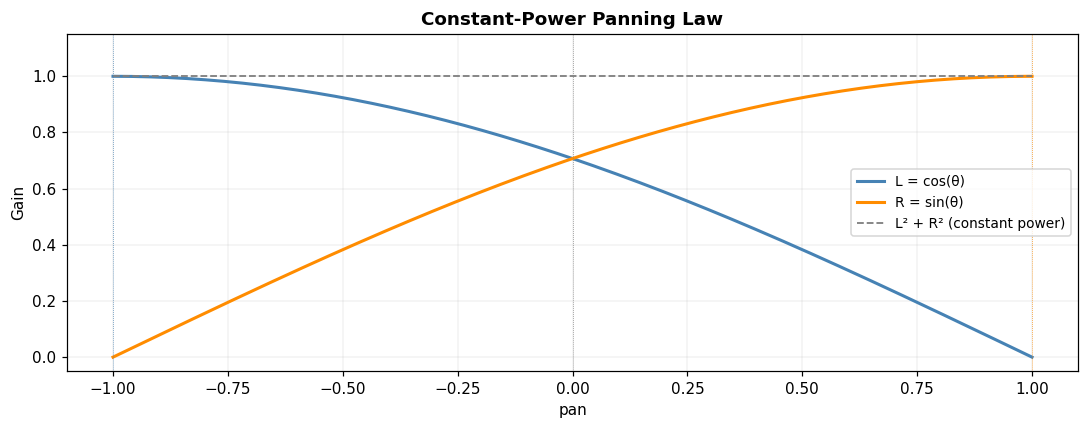

In [3]:
pan_vals = np.linspace(-1, 1, 200)
theta = (pan_vals + 1) * (np.pi / 4)
L_gain = np.cos(theta)
R_gain = np.sin(theta)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pan_vals, L_gain, color='steelblue', linewidth=2, label='L = cos(θ)')
ax.plot(pan_vals, R_gain, color='darkorange', linewidth=2, label='R = sin(θ)')
ax.plot(pan_vals, L_gain**2 + R_gain**2, color='gray', linewidth=1.2,
        linestyle='--', label='L² + R² (constant power)')
ax.set_xlabel('pan')
ax.set_ylabel('Gain')
ax.set_title('Constant-Power Panning Law', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linewidth=0.3, alpha=0.5)
ax.set_ylim(-0.05, 1.15)
ax.axvline(-1, color='steelblue', linewidth=0.5, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(1, color='darkorange', linewidth=0.5, linestyle=':')
plt.tight_layout()
plt.show()

## Verify Echo Positions and Amplitudes

With integer `delay_seconds × fs`, the tap amplitudes are exact. Confirm that
each tap lands at the expected sample and the constant-power invariant `L² + R² = gain²` holds.

In [4]:
impulse = np.zeros(4096)
impulse[0] = 1.0

verify_taps = [
    (500 / FS, 1.0,  -1.0),   # 500 samples, full left
    (1000 / FS, 0.7,  0.0),   # 1000 samples, centre
    (1500 / FS, 0.5,  1.0),   # 1500 samples, full right
]

_, L, R = multitap_delay(impulse, FS, verify_taps)

print(f'Tap 1 (delay=500, gain=1.0, pan=-1 → full left):')
print(f'  L[500] = {L[500]:.6f}  (expected 1.000000)')
print(f'  R[500] = {R[500]:.6f}  (expected 0.000000)')
print(f'  L²+R²  = {L[500]**2 + R[500]**2:.6f}  (expected 1.000000)')
print()
print(f'Tap 2 (delay=1000, gain=0.7, pan=0 → centre):')
l_exp = 0.7 * np.cos(np.pi / 4)
r_exp = 0.7 * np.sin(np.pi / 4)
print(f'  L[1000] = {L[1000]:.6f}  (expected {l_exp:.6f})')
print(f'  R[1000] = {R[1000]:.6f}  (expected {r_exp:.6f})')
print(f'  L²+R²   = {L[1000]**2 + R[1000]**2:.6f}  (expected {0.7**2:.6f})')
print()
print(f'Tap 3 (delay=1500, gain=0.5, pan=+1 → full right):')
print(f'  L[1500] = {L[1500]:.6f}  (expected 0.000000)')
print(f'  R[1500] = {R[1500]:.6f}  (expected 0.500000)')
print(f'  L²+R²   = {L[1500]**2 + R[1500]**2:.6f}  (expected {0.5**2:.6f})')

Tap 1 (delay=500, gain=1.0, pan=-1 → full left):
  L[500] = 1.000000  (expected 1.000000)
  R[500] = 0.000000  (expected 0.000000)
  L²+R²  = 1.000000  (expected 1.000000)

Tap 2 (delay=1000, gain=0.7, pan=0 → centre):
  L[1000] = 0.494975  (expected 0.494975)
  R[1000] = 0.494975  (expected 0.494975)
  L²+R²   = 0.490000  (expected 0.490000)

Tap 3 (delay=1500, gain=0.5, pan=+1 → full right):
  L[1500] = 0.000000  (expected 0.000000)
  R[1500] = 0.500000  (expected 0.500000)
  L²+R²   = 0.250000  (expected 0.250000)


## Audio Examples

A short percussive burst (40 ms decaying sine at 300 Hz) routed through five taps, each at a different delay time, gain, and stereo position. The five "pings" fan out across the stereo field with decreasing gain.

In [5]:
from IPython.display import Audio, display

DUR_A = 3.0
N_A   = int(DUR_A * FS)

# A 40 ms decaying sine burst — gives each tap a short audible "ping"
n_burst = int(0.04 * FS)
t_burst = np.arange(n_burst) / FS
burst   = np.sin(2 * np.pi * 300 * t_burst) * np.exp(-t_burst * 60)
click_a = np.zeros(N_A)
click_a[:n_burst] = burst

TAPS_A = [
    (0.10, 0.90, -0.8),
    (0.20, 0.70,  0.6),
    (0.35, 0.55, -0.4),
    (0.52, 0.40,  0.9),
    (0.72, 0.25, -0.6),
]
_, L_a, R_a = multitap_delay(click_a, FS, TAPS_A)

stereo_a = np.array([L_a, R_a])
peak_a   = np.max(np.abs(stereo_a))

print("Multi-tap stereo delay — 5 echoes panned across the stereo field")
display(Audio(stereo_a / peak_a * 0.8, rate=FS))

Multi-tap stereo delay — 5 echoes panned across the stereo field
